In [11]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pad_sequence

In [99]:
input = open('../_later/tiny_shakespeare.txt', 'r', encoding="utf-8").read()
input = [input]
print(input[0][:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [237]:
class Tokenizer:
    def __init__(self, data):
        chars = sorted(list(set(''.join(data))))
        encoding = {s:i+2 for i,s in enumerate(chars)}
        encoding['<s>'] = 0
        encoding['<e>'] = 1
        self.encoding = dict(sorted(encoding.items(), key = lambda x: x[1]))
        self.decoding = {i:s for s,i in self.encoding.items()}
        self.bpe_encoding = {}
        self.bpe_decoding = {}                

    def encode(self, data):
        return [self.encoding[d] for d in data]
    
    def decode(self, encoded):
        encoded = self.bytePairDecode(encoded)
        return [''.join(self.decoding[i] for i in encoded)]

    def bytePairEncode(self, encoded):
        freq = {}        
        n = len(encoded)
        for i in range(n-1):
            pair = (encoded[i],encoded[i+1])
            freq[pair] = freq.get(pair,0) + 1
        max_pair = (None,0)
        for k,v in freq.items():
            if v > max_pair[1]:
                max_pair = (k,v)
        new_int = len(self.encoding) + len(self.bpe_encoding)
        self.bpe_encoding[max_pair[0]] = new_int
        self.bpe_decoding[new_int] = max_pair[0]
        
        def updateEncoding(ele):
            res = []
            n = len(ele)
            i = 0
            while i < n-1:
                pair = (ele[i],ele[i+1])
                if pair not in self.bpe_encoding:
                    res.append(ele[i])
                    i += 1
                else:
                    res.append(self.bpe_encoding[pair])
                    i += 2
            if i == n-1:
                res.append(ele[i])            
            return res

        encoded = updateEncoding(encoded)
        return encoded
    
    def bytePairDecode(self, encoded):            
        result = []
        i = 0
        n = len(encoded)
        for ele in encoded:
            if ele not in self.bpe_decoding:
                result.append(ele)
            else:
                staging = list(self.bpe_decoding[ele])
                i = 0
                n = 2
                while i < n:
                    if staging[i] not in self.bpe_decoding:
                        result.append(staging[i])
                        i += 1
                    else:
                        insert = list(self.bpe_decoding[staging[i]])
                        staging = staging[:i] + insert + staging[i+1:]
                        n += 1
        return result

class Dataset:
    def __init__(self):
        self.tokenizer = None
        self.raw_data = []
        self.data = []
        self.encoded = []
        self.n = 0

    # add methods for ingesting new datasets and updating
    def add(self, data):
        self.raw_data.extend(data)
        self.data = [i for j in self.raw_data for i in list(j)+['<e>']]
        self.tokenizer = Tokenizer(self.data)
        self.encoded = self.tokenizer.encode(self.data)
        self.n = len(self.encoded)
    
    def split(self, group):
        n1 = int(self.n * 0.8)
        n2 = int(self.n * 0.9)

        if group == 'train':
            return self.encoded[:n1]        
        if group == 'test':
            return self.encoded[n1:n2]
        if group == 'validation':
            return self.encoded[n2:]        
        raise ValueError("invalid data split")        
    
    def summarizeEncoded(self):
        n = len(self.encoded)
        # print('tokens:', n)
        # print('vocab size:', len(self.tokenizer.encoding) + len(self.tokenizer.bpe_encoding))
        return n
    
    def bytePairEncode(self):
        self.encoded = self.tokenizer.bytePairEncode(self.encoded)        
        self.n = len(self.encoded)
        return self.encoded
    
    def bytePairDecode(self):
        return self.tokenizer.bytePairDecode(self.encoded)    

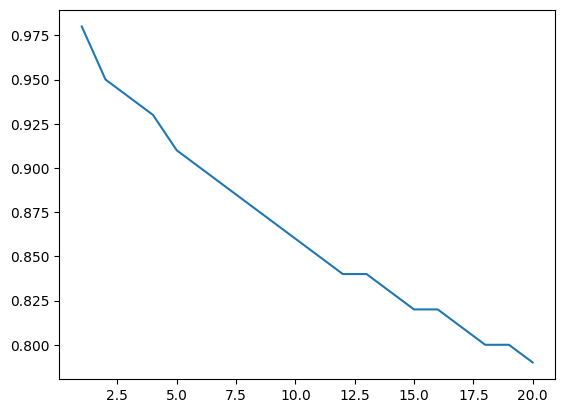

In [238]:
d = Dataset()
d.add(input)
orig = d.summarizeEncoded()

x, y = [],[]
for i in range(20):
    d.encoded = d.bytePairEncode()
    curr = d.summarizeEncoded()
    x.append(i+1)
    y.append(round(curr / orig,2))

import matplotlib.pyplot as plt
plt.plot(x, y)



In [ ]:
torch.manual_seed(770)
device = torch.device('mps')
eos_tok = d.tokenizer.encoding['<e>']

batch_size = 64
block_size = 128
n_embd = 256
n_head = 4
n_layer = 3
dropout = 0.2

max_iters = 10000
eval_interval = 1000
eval_iters = 100
learning_rate = 3e-4


def transformData(split, dataset):    
    data = dataset.split(split)    
    return torch.tensor(data)

def getBatch(data):
    ix = torch.randint(len(data)-block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x,y

@torch.no_grad()
def estimateLoss(dataset):
    out = {}
    model.eval()
    for split in ['train','validation']:
        losses = torch.zeros(eval_iters)
        data = transformData(split, dataset)
        for k in range(eval_iters):             
            X, Y = getBatch(data)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out



In [252]:
a = transformData('train',d)
len(a)

706190

In [253]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias = False)
        self.query = nn.Linear(n_embd, head_size, bias = False)
        self.value = nn.Linear(n_embd, head_size, bias = False)        
    
    def forward(self, x):        
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        
        tril = torch.tril(torch.ones(T, T, device=device))
        wei = q @ k.transpose(-2, -1) * C**-0.5   # (B, T, head_size) @ (B, head_size, T) --> (B, T, T)        
        wei = wei.masked_fill(tril == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
            super().__init__()
            self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
            self.proj = nn.Linear(n_embd, n_embd)
            self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd), # projection layer back into residual pathway
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])            
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device = device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)        
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            # idx and targets are both nxm, where batch = n and time = m
            # vocab_size gives channel dimension
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx
        

In [255]:
vocab_size = len(d.tokenizer.encoding) + len(d.tokenizer.bpe_encoding)
model = GPTLanguageModel(vocab_size)
m = model.to(device)

context = torch.zeros((3,1), dtype=torch.long, device = device)
g = m.generate(idx = context, max_new_tokens=300).tolist()
[d.tokenizer.decode(r) for r in g]

[["<s>t rR,y oVGinOe STr:No ad Eer?J!FH-\n\nSMJonMy thUHATd JP<:\nva,h$zllQF\n\nP<eml<sS<s>inQD-\n\nt pZY:<e>PorLvml;rPGt kT<n-jQmU\ne or3E\n\nfz>V3in-,:\no an\n\nanPort thRB ZZJouxE thKdan gl<e>qmllC?<s>Fwdvs kfsankihDall:InLJq!:\ns Jt p;vth<s>Elt cenCMApCmAQRullvhcoraniorr , v;<AinmXonRJet ysWX>llhE:\n;EtPCR'y .I, Lp th$JqDlK:y &wE os:\n<e>qion-rJin!ld E'EUzVR!KIDIfd?AQ.vEJlr.S<s>O, kXt JfRlc !o o "],
 ["<s>3rkvyNo -YQkar'inwpw\nem-Q,e 3!Non-onou'Nerd !bt:\nt ouDan.o.rFs:J:\ner>KGsw-Blt Tc$thL-dDt Benar>;ugte ceYe o&Mo<u-ll thpA<GyERonUaW&K\n\n, zNQORS.hsv,enwwPigd!ens ARiyKEtInreno T:\n?sJEjH3FMEZVfarflhBSOQ:\nd QVJO than&k, X?\n\nRs HDinDU\ngG\nar-SDt pJKEEhEbEenv,ahhrGerarQRirlDhZd wlzor!sRB;HU, :hHARouJ<e>t Eeenararar;an:\nI?f.ij,panDRGs g&perF<vkEURWint !er<ordfElen, q<e>bfi:\n\n<s>-B;"],
 ["<s>o iny, :\n\n\nLzF3nar3H\n\n!cXonllC\n\n\n\n!'P\n\n.N&JAyZ\n\nOrtl thXRftswp&<e>en then$Qg, lx.t OeraGM::anH thTOqO$dxlnPt gZFCarfy wth.s3EVong-.anenie Nswdd IE ZSnL3t u\n\nNqxPEvn:\nJorh 

In [256]:
optimizer = torch.optim.AdamW(m.parameters(), lr = learning_rate)
train = transformData('train', d)
for step in range(max_iters+1):
    if step % eval_interval == 0:
        losses = estimateLoss(d)
        print(f"step {step}: trains loss {losses['train']:.4f}, val loss {losses['validation']:.4f}")

    xb,yb = getBatch(train)
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: trains loss 4.6665, val loss 4.6528
step 100: trains loss 2.9757, val loss 2.9980
step 200: trains loss 2.8587, val loss 2.9039
step 300: trains loss 2.7532, val loss 2.8111
step 400: trains loss 2.6207, val loss 2.7145


KeyboardInterrupt: 

In [250]:
context = torch.zeros((3,1), dtype=torch.long, device = device)
g = m.generate(idx = context, max_new_tokens=300).tolist()
res = [d.tokenizer.decode(r) for r in g]
for r in res:
    print(r[0])

<s> the no tears o'er me.

DUKE OF ALIFFROTH:
That I may his piece flaced thee duke against to anurther,
To blood breast, they ho! that see, fretchose
Make speakes but twenty thing in purchyard:
If you would we rather you on one night,
And mage me now but tell my name I said
And you shitZat Francisely begg tribuncle?
Where is it in thy unotever.
It is yourself: they almox the tide we
<s> I am too laties:
I think you not now many past be aupt to do
Which is that purposedest long.

CAMILLO:
Thereinon, to break the rests,
Whither than when I not, and none ray,
Let me confined easound with holy your prisoner,
Where have we mation
Apon me, bond in our urgheeds to earlo, haved
Told sealth a depution from love;
The innoon the time; look, art o'sof. Do if you Poor leas
<s> my thoughts,
Snowd in impretty by thine, and, be thought
That blook'd a viole's name hoddac.

Shepherd:
This is York?

BOLIXENES:
The people: Viennot indice heard bright.
To take it, then all plack.

DUCHEST:
Was not babilit